# 02 — Classical NLP + Bag-of-Words baseline


Goals:
1. Demonstrate **classical NLP preprocessing**
2. Demonstrate a **Bag-of-Words** model
3. Train **two separate models**:
   - `Rating` as a **regression** problem
   - `Recommended` as a **classification** problem
4. Evaluate the models using the competition metric idea:
   - Spearman correlation for `Rating`
   - Spearman correlation for `Recommended`
   - mean of the two
5. Create a Kaggle submission file

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import Ridge, LogisticRegression

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

In [2]:
train = pd.read_csv("../data/rawdata/train.csv")
test = pd.read_csv("../data/rawdata/test.csv")
sample_sub = pd.read_csv("../data/rawdata/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_sub.shape)


Train shape: (14091, 10)
Test shape: (9395, 8)
Sample submission shape: (9395, 3)


In [3]:
display(train.head())
display(test.head())
display(sample_sub.head())

,Id,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended
0,17274,34,Cute fall/holiday top,"Love this top! the quality is magnificent and the pattern is even cuter in person. i'm 5'4"", 125 lbs and bought my normal size s which fits excellently. it's pretty flouncy and roomy, which is nic...",1,General,Tops,Blouses,5,1
1,5921,35,NaN,NaN,0,General,Tops,Blouses,5,1
2,16479,40,Disappointed,"Sleeves were tight, was difficult to put on ?. for the price, you want to love the shirt. sending it back.",15,General,Tops,Blouses,2,0
3,1925,28,Gorgeous detailing,"I never write reviews but this clothe is so fantastic i felt compelled to write one. it has unbelievably gorgeous detailing, from delicate beading and sequins on the bodice to the three layers of ...",3,General Petite,Clothes,Clothes,5,1
4,5691,39,Cute and comfortable tee!,Love this tshirt! casual but can be clotheed up with wedges and a scarf!,0,General,Tops,Knits,5,1


,Id,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category
0,21403,53,Magnificent clothe!,"In contrast to the other reviewer, i love this clothe. worth the sale price at least.",4,General,Clothes,Clothes
1,22553,51,Shapeless tent,I tried this on in the store and it was huge. i couldn't try on a smaller size because they only had a 2 and 4. i tried on my usual size 12. i don't think the embroidery is as pretty in person eit...,2,General,Clothes,Clothes
2,17436,59,Versatile and then some,"I thought this was a fun piece to have, but didn't realize how versatile it was until i got home and started mixing it with either casual shoes, or clotheing it up with fancier accessories.\ni lov...",1,General,Bottoms,Trousers
3,4293,48,So simple but so cute!,"I bought the multi-color stripe and it is adorable! i am 5'9"", 135 lbs and purchased a size small. it is a excellent length and drapes well...not too tight at all. i received a ton of compliments ...",1,General,Clothes,Clothes
4,20149,46,Magnificent simple tank,"The wide strap style is very flattering. this tank is fitted in my normal size small, it fits like the model in the cobalt blue color. i'm 5'7"" 120lbs. if you want more room, i'd size up. it is lo...",0,Initmates,Intimate,Layering


,Id,Rating,Recommended
0,21403,2,1
1,22553,5,0
2,17436,1,1
3,4293,1,0
4,20149,4,0


## 1. Text preprocessing and feature engineering


Important idea:
- Missing text is not only a cleaning issue.
- It may also contain information.

1. create binary indicators for missing title/review
2. fill missing text with empty strings so NLP methods can work
3. create combined text
4. create simple handcrafted features such as text lengths

In [4]:
def clean_text(text):
    """
    Light text cleaning for classical NLP.
    We keep it simple on purpose:
    - lowercase
    - remove extra whitespace
    - keep words largely intact
    We do NOT aggressively remove stopwords because words like 'not', 'no', 'too'
    may be important for sentiment.
    """
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def preprocess_reviews(df):
    df = df.copy()
    
    # 1) Missingness indicators BEFORE fillna
    df["title_missing"] = df["Review_Title"].isna().astype(int)
    df["review_missing"] = df["Review"].isna().astype(int)
    
    # 2) Fill missing text so text models can process it
    df["Review_Title"] = df["Review_Title"].fillna("")
    df["Review"] = df["Review"].fillna("")
    
    # 3) Light cleaning
    df["Review_Title_clean"] = df["Review_Title"].apply(clean_text)
    df["Review_clean"] = df["Review"].apply(clean_text)
    
    # 4) Combine title + review into one field for Bag-of-Words
    df["full_text"] = (
        df["Review_Title_clean"] + " " + df["Review_clean"]
    ).str.strip()
    
    # 5) Length-based features
    df["title_len_words"] = df["Review_Title_clean"].str.split().str.len()
    df["review_len_words"] = df["Review_clean"].str.split().str.len()
    
    # 6) Optional transformed numeric feature for skewed counts
    df["log_Pos_Feedback_Cnt"] = np.log1p(df["Pos_Feedback_Cnt"])
    
    return df

In [5]:
train_p = preprocess_reviews(train)
test_p = preprocess_reviews(test)

In [6]:
train_p[[
    "Review_Title", "Review",
    "title_missing", "review_missing",
    "title_len_words", "review_len_words",
    "full_text"
]].head(10)

,Review_Title,Review,title_missing,review_missing,title_len_words,review_len_words,full_text
0,Cute fall/holiday top,"Love this top! the quality is magnificent and the pattern is even cuter in person. i'm 5'4"", 125 lbs and bought my normal size s which fits excellently. it's pretty flouncy and roomy, which is nic...",0,0,3,62,"cute fall/holiday top love this top! the quality is magnificent and the pattern is even cuter in person. i'm 5'4"", 125 lbs and bought my normal size s which fits excellently. it's pretty flouncy a..."
1,,,1,1,0,0,
2,Disappointed,"Sleeves were tight, was difficult to put on ?. for the price, you want to love the shirt. sending it back.",0,0,1,21,"disappointed sleeves were tight, was difficult to put on ?. for the price, you want to love the shirt. sending it back."
3,Gorgeous detailing,"I never write reviews but this clothe is so fantastic i felt compelled to write one. it has unbelievably gorgeous detailing, from delicate beading and sequins on the bodice to the three layers of ...",0,0,2,68,"gorgeous detailing i never write reviews but this clothe is so fantastic i felt compelled to write one. it has unbelievably gorgeous detailing, from delicate beading and sequins on the bodice to t..."
4,Cute and comfortable tee!,Love this tshirt! casual but can be clotheed up with wedges and a scarf!,0,0,4,14,cute and comfortable tee! love this tshirt! casual but can be clotheed up with wedges and a scarf!
5,Disappointed,"I was so smitten by this shirt when i saw it online. i love embroidery and purple is my preferred color. i am a size 10 and decided to order an l. the shoulders fit well, but the rest of it was hu...",0,0,1,96,"disappointed i was so smitten by this shirt when i saw it online. i love embroidery and purple is my preferred color. i am a size 10 and decided to order an l. the shoulders fit well, but the rest..."
6,,"Love these jeans!! i ordered one pair and liked them so much i ordered another right away! i ordered the 26 regular.\nyes, they are too long (i'm 5'4 1/2""# for flats, but look fantastic with heels...",1,0,0,99,"love these jeans!! i ordered one pair and liked them so much i ordered another right away! i ordered the 26 regular. yes, they are too long (i'm 5'4 1/2""# for flats, but look fantastic with heels ..."
7,Very large; lace is kinda coarse,"Thought i'd love this top; i'm a sucker for lace anything from retailer. but i found the lace, while pretty, to be quite rough, which to me indicates a lower quality. and i guess i should've know...",0,0,6,62,"very large; lace is kinda coarse thought i'd love this top; i'm a sucker for lace anything from retailer. but i found the lace, while pretty, to be quite rough, which to me indicates a lower quali..."
8,My new preferred jean!,"Paige denim has done it again with this version of the hoxton high rise. no matter how many times i tell myself that i will find a less expensive pair of jeans, i never can find jeans that fit as ...",0,0,4,101,"my new preferred jean! paige denim has done it again with this version of the hoxton high rise. no matter how many times i tell myself that i will find a less expensive pair of jeans, i never can ..."
9,Pirate sleeves,"The beadwork is gorgeous, but the sleeves are so puffy, it looks as though you're wearing shoulder pads. the fabric of the shirt isn't that fabulous either.",0,0,2,27,"pirate sleeves the beadwork is gorgeous, but the sleeves are so puffy, it looks as though you're wearing shoulder pads. the fabric of the shirt isn't that fabulous either."


## 2. Check whether missingness itself may be informative

missing title/review may matter,
we directly test whether rows with missing text have different average targets.

In [7]:
print("Average targets by title_missing")
display(
    train_p.groupby("title_missing")[["Rating", "Recommended"]]
    .agg(["mean", "count"])
)

print("\nAverage targets by review_missing")
display(
    train_p.groupby("review_missing")[["Rating", "Recommended"]]
    .agg(["mean", "count"])
)

Average targets by title_missing


Rating        Recommended       
                   mean  count        mean  count
title_missing                                    
0              4.187095  11732    0.819127  11732
1              4.250954   2359    0.839339   2359


Average targets by review_missing


Rating        Recommended       
                    mean  count        mean  count
review_missing                                    
0               4.185090  13588    0.818664  13588
1               4.540755    503    0.926441    503

The analysis shows that missingness in text fields is informative rather than purely accidental. Reviews with missing titles have slightly higher average ratings and recommendation rates than reviews with titles. The effect is much stronger for missing review bodies: rows without a review body have substantially higher mean rating and recommendation rate. This suggests that missing text should not only be handled by replacing NaN with empty strings for vectorization, but also explicitly modeled through binary missingness indicators.

In [9]:
print("Share of missing title:")
display(train_p["title_missing"].value_counts(normalize=True).rename("proportion"))

print("\nShare of missing review:")
display(train_p["review_missing"].value_counts(normalize=True).rename("proportion"))

Share of missing title:


title_missing
0    0.832588
1    0.167412
Name: proportion, dtype: float64


Share of missing review:


review_missing
0    0.964303
1    0.035697
Name: proportion, dtype: float64

In [10]:
pd.crosstab(train_p["review_missing"], train_p["Recommended"], normalize="index")

Recommended,0,1
review_missing,,
0,0.181336,0.818664
1,0.073559,0.926441


## 3. Train / validation split

We create a validation set to estimate model quality before generating a Kaggle submission.

Because both targets are imbalanced, we try to preserve their joint distribution
as much as possible in the split.

In [8]:
stratify_label = train_p["Rating"].astype(str) + "_" + train_p["Recommended"].astype(str)

try:
    train_df, val_df = train_test_split(
        train_p,
        test_size=0.2,
        random_state=42,
        stratify=stratify_label
    )
except ValueError:
    # fallback if some rare combinations are too small
    train_df, val_df = train_test_split(
        train_p,
        test_size=0.2,
        random_state=42,
        stratify=train_p["Recommended"]
    )

print("Train split:", train_df.shape)
print("Validation split:", val_df.shape)

Train split: (11272, 18)
Validation split: (2819, 18)


In [12]:
#separate targets
y_train_rating = train_df["Rating"]
y_val_rating = val_df["Rating"]

y_train_rec = train_df["Recommended"]
y_val_rec = val_df["Recommended"]

## 4. Evaluation functions

The Kaggle competition uses Mean Columnwise Spearman correlation.

So on validation we evaluate:
- Spearman for `Rating`
- Spearman for `Recommended`
- average of both

Why Spearman?
Because the competition does not care only about exact values.
It cares whether the model preserves the correct ranking/order.

In [13]:
def safe_spearman(y_true, y_pred):
    score = spearmanr(y_true, y_pred).statistic
    if pd.isna(score):
        return 0.0
    return float(score)


def evaluate_predictions(y_true_rating, y_pred_rating, y_true_rec, y_pred_rec):
    rating_score = safe_spearman(y_true_rating, y_pred_rating)
    rec_score = safe_spearman(y_true_rec, y_pred_rec)
    mean_score = (rating_score + rec_score) / 2
    
    return pd.DataFrame({
        "target": ["Rating", "Recommended", "Mean"],
        "spearman": [rating_score, rec_score, mean_score]
    })

## 5. Define the feature groups

We combine:
- text features from Bag-of-Words
- categorical metadata
- numeric / handcrafted features

In [14]:
text_feature = "full_text"

cat_features = ["Division", "Department", "Product_Category"]

num_features = [
    "Age",
    "Pos_Feedback_Cnt",
    "log_Pos_Feedback_Cnt",
    "title_missing",
    "review_missing",
    "title_len_words",
    "review_len_words"
]

print("Text feature:", text_feature)
print("Categorical features:", cat_features)
print("Numeric features:", num_features)

Text feature: full_text
Categorical features: ['Division', 'Department', 'Product_Category']
Numeric features: ['Age', 'Pos_Feedback_Cnt', 'log_Pos_Feedback_Cnt', 'title_missing', 'review_missing', 'title_len_words', 'review_len_words']


We are not using only text.
We are also using metadata and handcrafted features.

## 6. Build the preprocessing pipeline

We use:
- `CountVectorizer` for Bag-of-Words
- `OneHotEncoder` for categorical features
- median imputation + scaling for numeric features

All of them are combined in one `ColumnTransformer`.

Numeric branch:

fills missing numeric values with the median
scales numeric values with MaxAbsScaler

MaxAbsScaler works well with sparse-style pipelines.

Categorical branch:

fills missing categories with the most frequent value
one-hot encodes categories into binary columns

In [15]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MaxAbsScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
#Bag of words processor 

bow_preprocessor = ColumnTransformer([
    ("text", CountVectorizer(
        min_df=5,
        max_features=30000,
        ngram_range=(1, 2),
        lowercase=False
    ), text_feature),
    
    ("cat", categorical_preprocessor, cat_features),
    ("num", numeric_preprocessor, num_features)
])

"""
Text branch

CountVectorizer turns text into counts of words / phrases.

We use:

min_df=5
ignore very rare words that appear in fewer than 5 documents
max_features=30000
keep vocabulary size manageable
ngram_range=(1, 2)
use:
single words like small
two-word phrases like too small

This is important because phrases often carry stronger sentiment than single words.

Why lowercase=False

Because we already lowercased in our own clean_text function.
    
"""

'\nText branch\n\nCountVectorizer turns text into counts of words / phrases.\n\nWe use:\n\nmin_df=5\nignore very rare words that appear in fewer than 5 documents\nmax_features=30000\nkeep vocabulary size manageable\nngram_range=(1, 2)\nuse:\nsingle words like small\ntwo-word phrases like too small\n\nThis is important because phrases often carry stronger sentiment than single words.\n\nWhy lowercase=False\n\nBecause we already lowercased in our own clean_text function.\n\n'

## 7. Build the two separate models

- `Rating` will be modeled with **Ridge regression**
- `Recommended` will be modeled with **Logistic Regression**

Why?
- `Rating` is an ordered score from 1 to 5, so a regression formulation is reasonable
- `Recommended` is binary, so classification is appropriate


Rating model

We use Ridge regression:

works well with many sparse Bag-of-Words features
produces continuous outputs, which is useful for Spearman ranking
Recommended model

We use Logistic Regression:

a standard strong baseline for text classification
class_weight="balanced" helps because Recommended=1 is much more common than 0

In [18]:
rating_model = Pipeline([
    ("preprocessor", bow_preprocessor),
    ("model", Ridge(alpha=3.0))
])

recommended_model = Pipeline([
    ("preprocessor", bow_preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

In [19]:
## 8. Fit the models

rating_model.fit(train_df, y_train_rating)
recommended_model.fit(train_df, y_train_rec)

print("Both models trained.")

Both models trained.


## 9. Generate validation predictions

For Spearman correlation, continuous predictions are often better than hard classes.

So we compare:
- continuous vs rounded predictions for `Rating`
- probability vs hard labels for `Recommended`

In [21]:
# Rating predictions
val_rating_pred_cont = rating_model.predict(val_df)
val_rating_pred_cont = np.clip(val_rating_pred_cont, 1, 5)

val_rating_pred_round = np.clip(np.rint(val_rating_pred_cont), 1, 5)

# Recommended predictions
val_rec_pred_prob = recommended_model.predict_proba(val_df)[:, 1]
val_rec_pred_label = recommended_model.predict(val_df)

"""
    
 We create:

val_rating_pred_cont → continuous predictions like 4.32
val_rating_pred_round → rounded predictions like 4

Why compare them?
Because Spearman often prefers continuous outputs, but we want to verify.

For Recommended

We create:

val_rec_pred_prob → probability of class 1
val_rec_pred_label → hard 0/1 prediction

Again, probability usually preserves ranking better.
    
"""

'\n\n We create:\n\nval_rating_pred_cont → continuous predictions like 4.32\nval_rating_pred_round → rounded predictions like 4\n\nWhy compare them?\nBecause Spearman often prefers continuous outputs, but we want to verify.\n\nFor Recommended\n\nWe create:\n\nval_rec_pred_prob → probability of class 1\nval_rec_pred_label → hard 0/1 prediction\n\nAgain, probability usually preserves ranking better.\n\n'

In [22]:
results = []

rating_options = {
    "rating_continuous": val_rating_pred_cont,
    "rating_rounded": val_rating_pred_round
}

rec_options = {
    "rec_probability": val_rec_pred_prob,
    "rec_hard_label": val_rec_pred_label
}

for rating_name, rating_pred in rating_options.items():
    for rec_name, rec_pred in rec_options.items():
        score_df = evaluate_predictions(
            y_val_rating, rating_pred,
            y_val_rec, rec_pred
        )
        mean_score = score_df.loc[score_df["target"] == "Mean", "spearman"].iloc[0]
        
        results.append({
            "rating_prediction_type": rating_name,
            "recommended_prediction_type": rec_name,
            "mean_spearman": mean_score,
            "rating_spearman": score_df.loc[score_df["target"] == "Rating", "spearman"].iloc[0],
            "recommended_spearman": score_df.loc[score_df["target"] == "Recommended", "spearman"].iloc[0]
        })

results_df = pd.DataFrame(results).sort_values("mean_spearman", ascending=False)
results_df

,rating_prediction_type,recommended_prediction_type,mean_spearman,rating_spearman,recommended_spearman
1,rating_continuous,rec_hard_label,0.661575,0.622724,0.700425
3,rating_rounded,rec_hard_label,0.654405,0.608385,0.700425
0,rating_continuous,rec_probability,0.599172,0.622724,0.575621
2,rating_rounded,rec_probability,0.592003,0.608385,0.575621


It compares 4 choices:

continuous rating + probability recommendation
continuous rating + hard-label recommendation
rounded rating + probability recommendation
rounded rating + hard-label recommendation

In [23]:
## 10. Inspect the best current strategy
best_row = results_df.iloc[0]
best_row

rating_prediction_type         rating_continuous
recommended_prediction_type       rec_hard_label
mean_spearman                           0.661575
rating_spearman                         0.622724
recommended_spearman                    0.700425
Name: 1, dtype: object

In [30]:
summary_scores = evaluate_predictions(
    y_val_rating, val_rating_pred_cont,
    y_val_rec, val_rec_pred_label
)

summary_scores

,target,spearman
0,Rating,0.622724
1,Recommended,0.700425
2,Mean,0.661575


## 11. Interpret the learned text features

One advantage of classical NLP models is interpretability.

We can inspect which words / phrases push the model:
- toward higher or lower `Rating`
- toward recommending or not recommending



This extracts the words and phrases with the strongest positive and negative coefficients.

Why is this valuable?
Because it helps you explain that the model is learning sensible text patterns.

In [31]:
def extract_top_text_features(fitted_pipeline, top_n=20):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    
    feature_names = preprocessor.get_feature_names_out()
    coefs = model.coef_.ravel()
    
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs
    })
    
    # keep only text features
    text_coef_df = coef_df[coef_df["feature"].str.startswith("text__")].copy()
    text_coef_df["feature"] = text_coef_df["feature"].str.replace("text__", "", regex=False)
    
    most_negative = text_coef_df.sort_values("coef", ascending=True).head(top_n)
    most_positive = text_coef_df.sort_values("coef", ascending=False).head(top_n)
    
    return most_negative, most_positive

In [32]:
neg_rec, pos_rec = extract_top_text_features(recommended_model, top_n=20)

print("Top words/phrases associated with NOT recommending:")
display(neg_rec)

print("\nTop words/phrases associated with recommending:")
display(pos_rec)

Top words/phrases associated with NOT recommending:


,feature,coef
18020,to love,-2.029446
18706,unflattering,-1.551739
7680,horrible,-1.487067
10641,meh,-1.432056
7757,huge,-1.415805
4982,disappointed,-1.405004
13052,poor,-1.391826
1997,awful,-1.366352
13839,returned,-1.341354
14403,shapeless,-1.313402



Top words/phrases associated with recommending:


,feature,coef
11591,not too,1.296730
5533,excellent,1.236577
18729,unique,1.127396
6981,gorgeous,1.066579
4852,details,1.056046
2250,beautiful,1.040502
802,amazing,1.026575
10178,magnificent,0.999020
4150,comfy,0.997408
10056,love this,0.973067


In [27]:
neg_rating, pos_rating = extract_top_text_features(rating_model, top_n=20)

print("Top words/phrases associated with LOWER rating:")
display(neg_rating)

print("\nTop words/phrases associated with HIGHER rating:")
display(pos_rating)


Top words/phrases associated with LOWER rating:


,feature,coef
7680,horrible,-0.716238
15151,small too,-0.612152
13052,poor,-0.534719
18020,to love,-0.487616
2035,back looks,-0.484546
4982,disappointed,-0.480572
14052,ruined,-0.475266
15369,so wanted,-0.474034
18706,unflattering,-0.464540
11510,not good,-0.459845



Top words/phrases associated with HIGHER rating:


,feature,coef
4221,completely stunning,0.385041
3869,clothes but,0.384918
14988,sleeve and,0.381175
2962,breast,0.381029
5954,fell on,0.364289
18527,try it,0.359751
4046,colors the,0.355581
15090,sm,0.351930
11487,not disappointed,0.349438
13841,returned for,0.346902


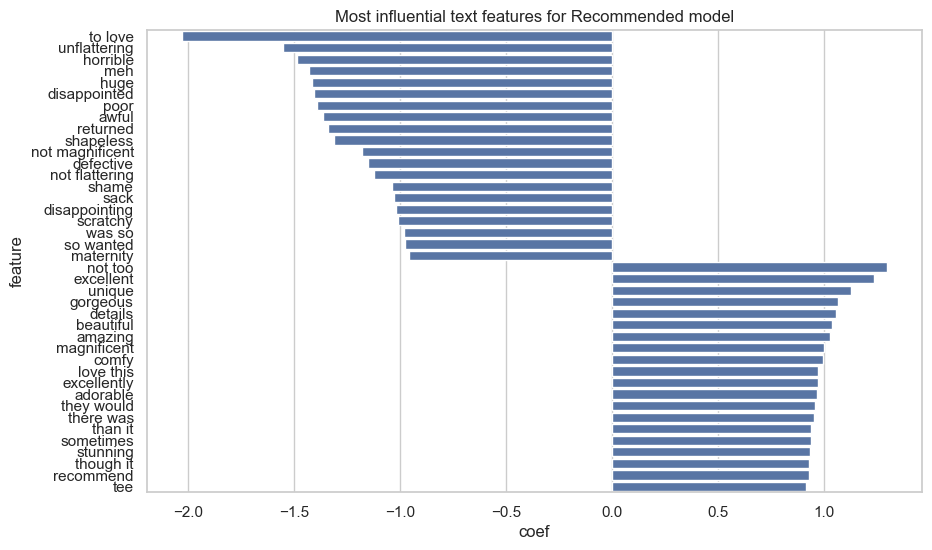

In [28]:
## 12. Optional: visualize coefficient magnitudes

plt.figure(figsize=(10, 6))
plot_df = pd.concat([
    neg_rec.assign(direction="negative"),
    pos_rec.assign(direction="positive")
], axis=0)

sns.barplot(data=plot_df, x="coef", y="feature")
plt.title("Most influential text features for Recommended model")
plt.show()

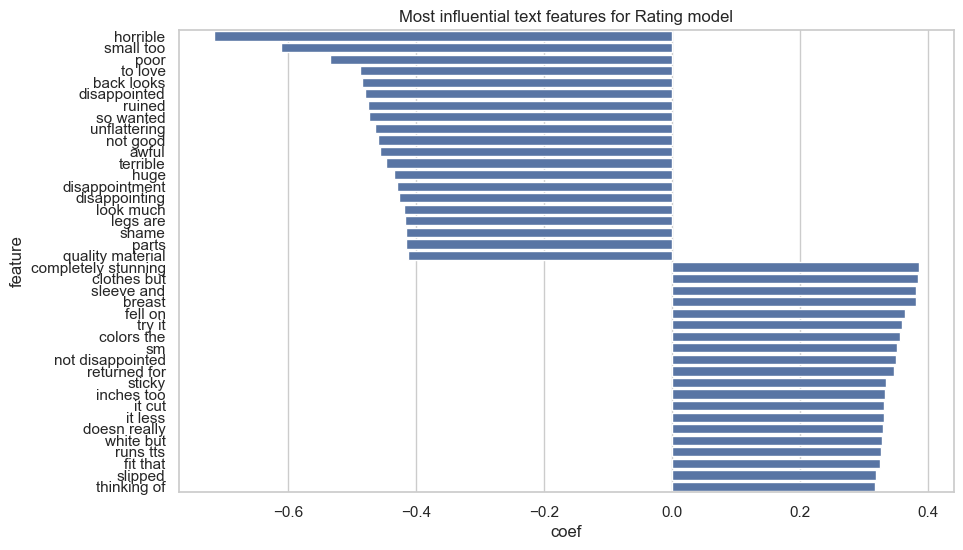

In [29]:
plt.figure(figsize=(10, 6))
plot_df = pd.concat([
    neg_rating.assign(direction="negative"),
    pos_rating.assign(direction="positive")
], axis=0)

sns.barplot(data=plot_df, x="coef", y="feature")
plt.title("Most influential text features for Rating model")
plt.show()

In [33]:
def show_examples_with_phrase(df, phrase, n=10):
    mask = df["full_text"].str.contains(rf"\b{re.escape(phrase)}\b", regex=True, na=False)
    cols = ["Rating", "Recommended", "Review_Title", "Review"]
    return df.loc[mask, cols].head(n)

In [34]:
show_examples_with_phrase(train_p, "to love", n=15)

,Rating,Recommended,Review_Title,Review
2,2,0,Disappointed,"Sleeves were tight, was difficult to put on ?. for the price, you want to love the shirt. sending it back."
106,3,1,Mixed review,I wanted to love this shirt and thought i would based on the reviews. it runs really large however and while i love how flows it is i also looked pregnant. i am keeping though- looks nice layered ...
119,2,0,Wanted to love...,"I wanted to love this top, but it unfortunately did not work for me. the material has a nice weight and feel to it, and while i love the pattern, the shape leaves something to be desired. the cap ..."
125,4,1,"Nice, but...","These trousers arrived today. yippee. i really wanted to love them. i do like the color and the cut. not crazy about the fold-over waist. the fit through the waist, hips, and thighs is true to siz..."
147,1,0,"No, just no.","I wanted to love this. couldn't wait for it to arrive. unfortunately, it doesn't look anything like the picture. i usually wear a m/l in holding horses so i ordered a l but as soon as i held it ..."
155,2,0,"Had high hopes & really wanted to love it, but...","It just didn't work for me. i don't know if it is my fair complexion and untanned legs, but this clothe was a strike out. the orange floral design and beading is beautiful and the fitting i would ..."
180,4,1,,"I wanted to love these. the fabric was soft and they were good quality but they fit differently than the hyphen chinos and were too small. sadly, i had to return them."
423,2,0,,"I wanted to love this top. excellent weight, length, and shape. unfortunately, the seam goes right through the bust and just does not look right. if you are tiny on top, this will be lovely on you."
438,2,0,Must be tall & lean,"I wanted to love this coat so bad. the material is lovely and it's beautiful on the hanger but being tall and skinny is a must to pull it off. if you have any hips forget it (my hips are 38"")- you..."
451,1,0,So wanted to love.....,"I saw this top online and ordered immediately!\r\ni loved the color, lace, and unique details.\r\nsadly it just arrived and it is a disaster!\r\nthe lace is stiff and doesn't lay softly, and is ve..."


In [35]:
show_examples_with_phrase(train_p, "not too", n=15)

,Rating,Recommended,Review_Title,Review
28,5,1,Magnificent sweater & color!,This appealed to me online & it came in petite. during the promo in july i decided i shld order the petite small while they lasted although way too hot to even consider wearing until fall. glad i ...
44,5,1,Gorgeous,"I ordered this clothe for a special event and i am so incredibly happy with it! i am 5'1"", 97 lbs, 32b and ordered a 0 petite. fits like a glove. the clothe has a slight give to it, but main cloth..."
68,5,1,Preferred top!,"This is my preferred top! it is gorgeous, soft, & oh so comfortable. it's not too tight & works with leggings, jeans, or as an over-shirt. love it!"
92,4,1,Way cute,Nicely designed romper with an wide elastic waist band that can be worn on the hips or around the waist. not too short for this 60+ body and very comfy. i wear either a med. or large and went with...
107,5,1,Cute skirt,Have only tried on but it is a very cute skirt and i think will be comfortable to wear. i love the texture of the material. i do wish it came in other colors. it is a little heavier material but n...
124,5,1,,"I am 5'9"" and 138 pounds slender, but with a tummy. the small fit magnificent ,and i agree with the other reviewer that the elastic waist band is complimentary. the clothe flounces out a little, b..."
127,5,1,Magnificent!,"I know i'm going to get a lot of wear out of this t-shirt this summer. i have it in white, and it's not too see through, which is what i always worry about when i wear white shirts. it's simple bu..."
141,4,1,"Comfortable, casual and classic","I am 5'9 135lbs, small chest and narrow shoulders. the 6 fits me excellently. i love the fact that there is a hem, if i decide to let it down just a little. being over 60 and tall, it is so disapp..."
155,2,0,"Had high hopes & really wanted to love it, but...","It just didn't work for me. i don't know if it is my fair complexion and untanned legs, but this clothe was a strike out. the orange floral design and beading is beautiful and the fitting i would ..."
170,5,1,Flattering and attractive!!!!,"Love these shorts! not too tight and not too short! they match so many tops! tts for my hard to fit figure! magnificent for weekends, vacations, and just to be adorable in!"


Some learned coefficients appear counterintuitive when read in isolation, but this is expected in Bag-of-Words models with bigrams. For example, phrases such as “to love” may occur predominantly in negative constructions like “wanted to love this, but…”, while “not too” may occur in positive fit-related contexts such as “not too tight” or “not too short”. Therefore, coefficients should be interpreted as dataset-specific contextual signals rather than standalone sentiment labels.

In [36]:
summary_scores = evaluate_predictions(
    y_val_rating, val_rating_pred_cont,
    y_val_rec, val_rec_pred_label
)

summary_scores

,target,spearman
0,Rating,0.622724
1,Recommended,0.700425
2,Mean,0.661575


In [43]:
final_rating_model = Pipeline([
    ("preprocessor", bow_preprocessor),
    ("model", Ridge(alpha=3.0))
])

final_recommended_model = Pipeline([
    ("preprocessor", bow_preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

final_rating_model.fit(train_p, train_p["Rating"])
final_recommended_model.fit(train_p, train_p["Recommended"])

print("Final models trained on full training data.")

Final models trained on full training data.


In [44]:
test_rating_pred = final_rating_model.predict(test_p)

# clip to valid range, round, convert to integer
test_rating_pred = np.clip(np.rint(test_rating_pred), 1, 5).astype(int)

# hard class labels for Recommended
test_rec_pred = final_recommended_model.predict(test_p).astype(int)

print("Rating predictions shape:", test_rating_pred.shape)
print("Recommended predictions shape:", test_rec_pred.shape)

Rating predictions shape: (9395,)
Recommended predictions shape: (9395,)


In [45]:
submission = pd.DataFrame({
    "Id": test_p["Id"].astype(int),
    "Rating": test_rating_pred,
    "Recommended": test_rec_pred
})

submission.head()

,Id,Rating,Recommended
0,21403,5,1
1,22553,2,0
2,17436,4,1
3,4293,5,1
4,20149,4,1


In [49]:
submission.to_csv("submission_bow_separate_models_bestval_int.csv", index=False)
print("Saved: submission_bow_separate_models_bestval_int.csv")

Saved: submission_bow_separate_models_bestval_int.csv


In [47]:
print(submission.shape)
print(submission.dtypes)
print(submission.isna().sum())
display(submission.head())
display(submission["Rating"].value_counts().sort_index())
display(submission["Recommended"].value_counts().sort_index())

(9395, 3)
Id             int64
Rating         int64
Recommended    int64
dtype: object
Id             0
Rating         0
Recommended    0
dtype: int64


,Id,Rating,Recommended
0,21403,5,1
1,22553,2,0
2,17436,4,1
3,4293,5,1
4,20149,4,1


Rating
1     206
2     601
3    1350
4    3099
5    4139
Name: count, dtype: int64

Recommended
0    1802
1    7593
Name: count, dtype: int64

In [48]:
print(submission["Recommended"].value_counts(dropna=False))


Recommended
1    7593
0    1802
Name: count, dtype: int64


Although continuous regression outputs gave slightly better local Spearman scores for Rating, the competition submission format requires integer ratings from 1 to 5. Therefore, the final Kaggle submission uses rounded and clipped integer rating predictions together with hard class predictions for Recommended.